<a href="https://colab.research.google.com/github/LuthfiAdiHarianto/Belajar-MachineLearning/blob/main/Tugas_1_colaborative_filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install "numpy<2"


# Menentukan nama kolom karena u.data tidak punya header
columns = ['user_id', 'item_id', 'rating', 'timestamp']

# Membaca file dengan pemisah tab (\t)
df = pd.read_csv('u.data', sep='\t', names=columns)

5 data teratas

In [2]:
print(df.head())

   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596


total interaksi

In [3]:
print(f"\nTotal interaksi: {len(df)} baris")


Total interaksi: 100000 baris


## Data Cleaning

cek data kosong

In [4]:
print("Jumlah data kosong per kolom:")
print(df.isnull().sum())

Jumlah data kosong per kolom:
user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64


cek duplikat

In [5]:
duplicate_count = df.duplicated().sum()
print(f"\nJumlah data duplikat: {duplicate_count}")


Jumlah data duplikat: 0


## EDA ( Explanatory Data Analisis )

distribusi rating

/tmp/ipykernel_18927/1599199293.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


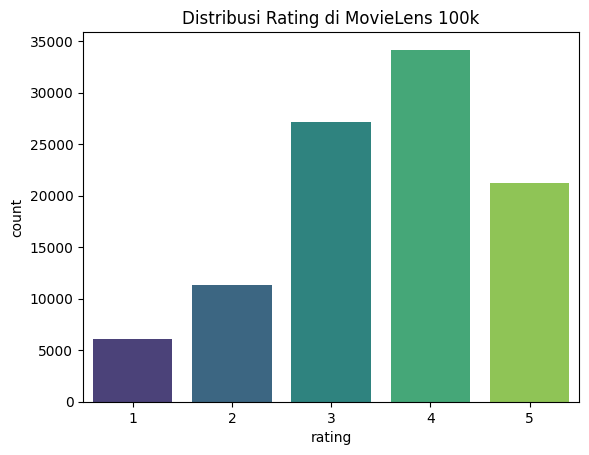

In [6]:
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Distribusi Rating di MovieLens 100k')
plt.show()

cek jumlah user dan item

In [7]:
n_users = df.user_id.nunique()
n_items = df.item_id.nunique()
print(f"Jumlah User Unik: {n_users}")
print(f"Jumlah Film Unik: {n_items}")

Jumlah User Unik: 943
Jumlah Film Unik: 1682


total kemungkinan interaksi

In [8]:
total_possible_interactions = n_users * n_items
actual_interactions = len(df)

sparsity

In [9]:
sparsity = (1 - (actual_interactions / total_possible_interactions)) * 100

print(f"Total Interaksi Maksimal: {total_possible_interactions}")
print(f"Interaksi yang Ada: {actual_interactions}")
print(f"Sparsity Dataset: {sparsity:.2f}%")

Total Interaksi Maksimal: 1586126
Interaksi yang Ada: 100000
Sparsity Dataset: 93.70%


jumlah rating per film

In [10]:
movie_counts = df.groupby('item_id').size().sort_values(ascending=False)

visualisasi

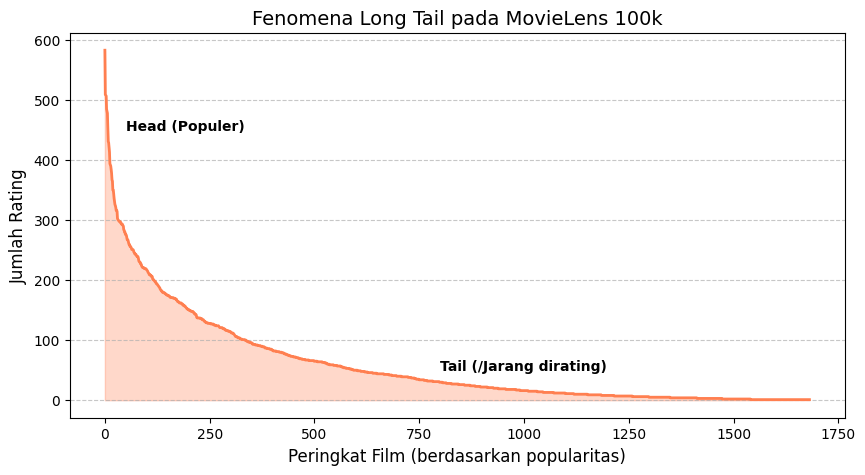

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(movie_counts.values, color='coral', linewidth=2)

plt.fill_between(range(len(movie_counts)), movie_counts.values, color='coral', alpha=0.3)

plt.title('Fenomena Long Tail pada MovieLens 100k', fontsize=14)
plt.xlabel('Peringkat Film (berdasarkan popularitas)', fontsize=12)
plt.ylabel('Jumlah Rating', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# catatan teks di grafik
plt.text(50, 450, 'Head (Populer)', fontsize=10, fontweight='bold')
plt.text(800, 50, 'Tail (/Jarang dirating)', fontsize=10, fontweight='bold')

plt.show()

## Model 1 Matrix Factorization Native

Load data ke format surprise

In [12]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy

skala rating 1-5

In [13]:
reader = Reader(rating_scale=(1, 5))

Load dataframe Pandas ke objek Dataset Surprise

In [14]:
data = Dataset.load_from_df(df[['user_id', 'item_id', 'rating']], reader)

split data 80 % latihan 20 % ujian

In [15]:
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

## Training Model


inisialisasi model

In [16]:
model_mf = SVD(n_factors=100, n_epochs=20, random_state=42)

prediksi

In [17]:
print("Sedang melatih model Matrix Factorization...")
model_mf.fit(trainset)

predictions = model_mf.test(testset)

Sedang melatih model Matrix Factorization...


skor akurasi rmse

In [18]:
rmse_mf = accuracy.rmse(predictions)
print(f"\nSkor RMSE Model 1: {rmse_mf:.4f}")

RMSE: 0.9352

Skor RMSE Model 1: 0.9352


## SVD

update library

In [19]:
from surprise.model_selection import GridSearchCV

paramater grid

In [20]:
param_grid = {
    'n_factors': [50, 100],
    'n_epochs': [20, 30],
    'lr_all': [0.005, 0.01],
    'reg_all': [0.02, 0.1]
}

In [21]:
print("Sedang mencari parameter terbaik (ini mungkin memakan waktu 1-2 menit)...")
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data)

Sedang mencari parameter terbaik (ini mungkin memakan waktu 1-2 menit)...


skor rmse

In [22]:
best_rmse = gs.best_score['rmse']
best_params = gs.best_params['rmse']

print(f"\nRMSE Terbaik untuk Model 2: {best_rmse:.4f}")
print(f"Parameter Terbaik: {best_params}")


RMSE Terbaik untuk Model 2: 0.9225
Parameter Terbaik: {'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}


test case manual

In [23]:
uid = str(1)  # ID User
iid = str(50) # ID Film

algo = gs.best_estimator['rmse']
algo.fit(trainset)
pred = algo.predict(uid, iid)

print(f"Prediksi rating User {uid} untuk Film {iid} adalah: {pred.est:.2f}")

Prediksi rating User 1 untuk Film 50 adalah: 3.53
